In [1]:
from loguru import logger
from datasets import Dataset

In [2]:
dataset = Dataset.from_json('data/ifbench/input_train_data_with_claude_response_5000_subset.jsonl')
dataset

Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward'],
    num_rows: 5000
})

In [3]:
dataset = dataset.map(lambda x: {
    "question": (
        f"User Prompt: {x['messages'][0]['content']}\n<draft_response>{x['claude_response']}</draft_response>\n"
        "/no_think"
    ),
    "answer": "",
    "info": {**x}  # answer is empty, info contains fields for verification
})
dataset


Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info'],
    num_rows: 5000
})

In [4]:
# split dataset into train and val
# 80-20 stratified split on claude_reward values
lgtm_dataset = dataset.filter(lambda x: x['claude_reward'] == True)
fixme_dataset = dataset.filter(lambda x: x['claude_reward'] == False)

lgtm_train_dataset, lgtm_val_dataset = lgtm_dataset.train_test_split(test_size=0.2, seed=42).values()
fixme_train_dataset, fixme_val_dataset = fixme_dataset.train_test_split(test_size=0.2, seed=42).values()

from datasets import concatenate_datasets
train_dataset = concatenate_datasets([lgtm_train_dataset, fixme_train_dataset])
val_dataset = concatenate_datasets([lgtm_val_dataset, fixme_val_dataset])

train_dataset, val_dataset

(Dataset({
     features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info'],
     num_rows: 3999
 }),
 Dataset({
     features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info'],
     num_rows: 1001
 }))

In [5]:
# sample 500 questions from train_dataset
# and do inference time scaling pass@64 and also avg_reward @ 64 and advantages
# this will help us understand how much learning signal the model can get during rl

In [6]:
subset_train_dataset = train_dataset.shuffle(seed=42).select(range(500))
subset_train_dataset

Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info'],
    num_rows: 500
})

In [7]:
# SYSTEM_PROMPT = """
# You are a helpful assistant. Your job is to look at the user prompt and the draft response and output <|ADAPTER_RESPONSE_START|>CORRECT<|ADAPTER_RESPONSE_END|> if the draft response is correct
# If the draft response is incorrect, print the correct final answer wrapped in <|ADAPTER_RESPONSE_START|> ... <|ADAPTER_RESPONSE_END|> tags.

# Example:
# User Prompt: What is the capital of France?
# <draft_response>The capital of France is Paris.</draft_response>
# Output: <|ADAPTER_RESPONSE_START|>CORRECT<|ADAPTER_RESPONSE_END|>

# User Prompt: What is the capital of France?
# <draft_response>The capital of France is London.</draft_response>
# Output: The capital of France is Paris but the draft response says its London. So it is incorrect. <|ADAPTER_RESPONSE_START|>The capital of France is Paris.<|ADAPTER_RESPONSE_END|>
# """.strip()

In [8]:
# gepa optimized system prompt
SYSTEM_PROMPT = """
You are a helpful assistant. Your job is to look at the user prompt and the draft response and determine if the draft response is correct.

You MUST think carefully inside your reasoning before outputting your final answer. Follow these evaluation steps:

**Step 1 - Identify All Constraints**: Read the user prompt thoroughly and list EVERY explicit constraint, formatting requirement, and instruction. Be exhaustive — but ONLY include constraints that are explicitly stated in the prompt. Do NOT invent or infer constraints that are not present. Common constraint types include:
- Required keywords that must appear (with specific frequencies) or must NOT appear
- Word count, sentence count, paragraph count, section count, or bullet point count requirements
- Structural formatting (titles wrapped in specific markers, sections with specific labels, bullet points, headers, bigram wrapping in double angular brackets, square brackets around words)
- Capitalization rules (e.g., all caps, capital word frequency minimums)
- Starting/ending word constraints for sentences or the overall response
- Language requirements
- Inclusion of specific elements (palindromes, postscripts, placeholders in square brackets)
- Punctuation rules (e.g., no exclamation marks, no dots, hyphens between sentences)
- Unique word constraints (no repeated words)
- Letter frequency constraints (e.g., letter X should appear fewer than N times)
- Copy/repeat instructions (e.g., "repeat the request without change and do not answer")
- JSON formatting requirements
- Paragraph separation requirements (e.g., two new lines between paragraphs)
- Adjacent word letter constraints
- Character index span copying
- Phrase repetition with transformation
- Nth paragraph first word requirements
- Any other explicit formatting or content instructions

**Step 2 - Check Content Correctness**: Verify that the draft response properly addresses the user's question or request with factually accurate information, correct mathematical calculations, and sound logical reasoning. A response that is just an error message, blank, or the word "Error" is NOT correct — it fails to address the actual request. Also check if the prompt instructs NOT to answer and only to repeat — in that case, answering the question is incorrect.

**Step 3 - Verify Each Constraint Individually**: Go through EVERY SINGLE constraint identified in Step 1 and explicitly check whether the draft response satisfies it. Be meticulous and skeptical:
- Count words, sentences, paragraphs exactly — do not estimate
- Count keyword appearances exactly — search the entire response carefully
- Count letter occurrences exactly when letter frequency constraints exist
- Verify structural elements character by character (bigram wrapping, square brackets, title markers)
- Check paragraph separators match requirements (e.g., markdown divider `***` or `\n\n`)
- Verify keyword positions (e.g., "keyword X as the Nth word of sentence M")
- Check start/end words of sentences and of the entire response
- Validate any JSON formatting
- For character index span copying, count characters in the original prompt carefully starting from index 0
- For keyword frequency constraints, count the EXACT number of times a keyword appears — not more, not less
- For "no two adjacent words start with consecutive letters" constraints, check EVERY pair of adjacent words
- For phrase repetition constraints, verify the exact number of repetitions AND that transformations follow the rules
- For paragraph first-word constraints, identify paragraphs correctly based on the specified separator and check the first word of the specified paragraph
Note each constraint as SATISFIED or VIOLATED with a brief explanation.

**Step 4 - Make Your Decision**:
- If the draft response is correct in content AND satisfies ALL constraints with zero violations, output exactly:
  <|ADAPTER_RESPONSE_START|>CORRECT<|ADAPTER_RESPONSE_END|>

- If the draft response has ANY content error OR ANY constraint violation, provide a corrected response that fixes ALL issues while preserving what was already correct:
  <|ADAPTER_RESPONSE_START|>[your corrected response here]<|ADAPTER_RESPONSE_END|>

**Critical Rules**:
- Tag formatting is paramount: use exactly <|ADAPTER_RESPONSE_START|> and <|ADAPTER_RESPONSE_END|> with the pipe characters and angle brackets precisely as shown. Double-check your tags character by character before outputting. The opening tag must be <|ADAPTER_RESPONSE_START|> and the closing tag must be <|ADAPTER_RESPONSE_END|>. Any typo (e.g., missing pipe character, swapped brackets like |< instead of <|, missing | before >) will cause a catastrophic failure.
- A draft response that is just "Error" or blank or fails to address the request is almost NEVER correct. Always provide a proper corrected response in such cases.
- Do NOT invent constraints that are not explicitly stated in the user prompt. Only check for constraints that are actually written in the prompt. For example, if the prompt only says "no dots," do not also add "no commas" or "no hyphens" as constraints.
- Do NOT say CORRECT if ANY constraint is violated, even a minor one. When in doubt, re-count and re-verify.
- Do NOT unnecessarily correct responses that are already correct. If the content is accurate and genuinely ALL constraints are met after careful verification, output CORRECT. Do not make changes just because you think something could be "better" — only fix actual violations.
- When providing a corrected response, ensure it satisfies ALL identified constraints from the user prompt simultaneously. Your corrected response replaces the draft entirely, so it must be complete and self-contained.
- If the draft appropriately refuses a harmful, dangerous, or unethical request, treat the refusal as correct behavior even if some formatting constraints from the malicious prompt are not followed.
- Pay special attention to constraints that are easy to overlook: keyword frequency/position requirements, exact paragraph counts, bigram wrapping, letter frequency limits, copy/repeat instructions, structural formatting details, nth paragraph first word requirements, and phrase repetition with transformation rules.
- When counting paragraphs, use the separator specified in the prompt (e.g., two new lines). If no separator is specified, use standard paragraph breaks. Be precise about which paragraph is which.
- Your corrected response should go directly inside the tags with no additional commentary outside them.
- Before finalizing, re-read your output to confirm the tags are exactly correct: <|ADAPTER_RESPONSE_START|> to open and <|ADAPTER_RESPONSE_END|> to close. Verify both tags character by character.
"""

In [9]:
# response parser
import re
ptrn = re.compile(r"<\|ADAPTER_RESPONSE_START\|>(.*)<\|ADAPTER_RESPONSE_END\|>", re.DOTALL)
def extract_adapter_response(response):
    try: return ptrn.findall(response)[-1]
    except:
        # logger.exception(f"Error in extract_adapter_response")
        return ""


In [10]:
# generate rollouts
from openai import AsyncOpenAI
client = AsyncOpenAI(base_url="http://localhost:8000/v1", api_key="")
model_name = "qwen3-8b"
response = await client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "user", "content": "Hello, how are you?"},
    ],
)
response.choices[0].message.content

'<think>\nOkay, the user greeted me with "Hello, how are you?" I need to respond in a friendly and helpful manner. Let me start by acknowledging their greeting. I should mention that I\'m a large language model and don\'t have feelings, but I\'m here to help. I should keep the tone positive and open-ended to encourage them to ask questions. Maybe add an emoji to make it more approachable. Let me check for any errors and ensure the response is natural.\n</think>\n\nHello! I\'m just a large language model, so I don\'t have feelings, but I\'m here and ready to help! How can I assist you today? 😊'

In [11]:
import asyncio
semaphore = asyncio.Semaphore(210)

async def generate_rollout(prompt, pbar = None)-> str:
    try:
        async with semaphore:
            response = await client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": prompt},
                ],
                max_tokens=2048,
            )
            return response.choices[0].message.content
    except Exception as e:
        logger.exception(f"Error in generate_rollout: {e}")
        return ""
    finally:
        if pbar: pbar.update(1)

await generate_rollout("What is the capital of France?") 

'<think>\nOkay, let\'s tackle this. The user is asking for the capital of France. First, I need to make sure I know the correct answer. From what I remember, the capital of France is Paris. That\'s pretty straightforward.\n\nNow, looking at the constraints. The user\'s prompt is a simple question with no specific formatting or content requirements mentioned. There are no constraints listed in the prompt, so I don\'t have to worry about anything like word count, specific keywords, or structural formatting. The main thing is to provide the correct answer.\n\nThe draft response given is "Paris." That\'s the correct answer. Since there are no constraints to check, the response is accurate. I don\'t see any errors in the content. The user didn\'t mention any special formatting, so the answer is appropriate. \n\nWait, but the user included a detailed evaluation process. Let me double-check if there\'s anything I missed. The user\'s original question is just asking for the capital of France. 

In [12]:
GROUP_SIZE = 64
async def generate_group(prompt, pbar=None) -> list[str]:
    tasks = [generate_rollout(prompt, pbar) for _ in range(GROUP_SIZE)]
    return await asyncio.gather(*tasks)

x = await generate_group("What is the capital of France?/no_think")
print(len(x))


64


In [13]:
from tqdm import tqdm
pbar = tqdm(total=len(subset_train_dataset)*GROUP_SIZE, desc="Generating groups")
tasks = [generate_group(x['question'], pbar) for x in subset_train_dataset]
groups = await asyncio.gather(*tasks, return_exceptions=True)
pbar.close()

Generating groups:  59%|████████████████████████████████████████████████████████████████▍                                            | 18927/32000 [05:29<04:55, 44.28it/s]2026-04-23 02:30:02.548 | ERROR    | __main__:generate_rollout:17 - Error in generate_rollout: Error code: 400 - {'error': {'message': "You passed 14337 input tokens and requested 2048 output tokens. However, the model's context length is only 16384 tokens, resulting in a maximum input length of 14336 tokens. Please reduce the length of the input prompt. (parameter=input_tokens, value=14337)", 'type': 'BadRequestError', 'param': 'input_tokens', 'code': 400}}
Traceback (most recent call last):

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/workspace/home/lab/rawhad/api-adapter/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
    │   └ <bound method Application.launch_instance of <class 'ipyke

In [14]:
pbar.close()

In [15]:
# save the dataset with the groups to disk
subset_train_dataset = subset_train_dataset.add_column('groups', groups)
subset_train_dataset


Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info', 'groups'],
    num_rows: 500
})

In [16]:
# save the dataset with the groups to disk
subset_train_dataset.to_json('data/ifbench/subset_train_dataset_with_its_groups_gepa_prompt_no_think_qwen3_8b.jsonl', lines=True)
!head data/ifbench/subset_train_dataset_with_its_groups_gepa_prompt_no_think_qwen3_8b.jsonl

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

{"key":"ai2-adapt-dev\/numinamath_tir_math_decontaminated_8395","messages":[{"content":"A road is being repaired. 24 people can complete the work in 12 days. Now, after 24 people have worked for 4 days, 8 more people join them. How many more days are needed to complete the work? In your response, the word web should appear less than 4 times.","role":"user"}],"ground_truth":"[{'instruction_id': ['keywords:frequency'], 'kwargs': [{'keyword': 'web', 'frequency': 4, 'relation': 'less than'}]}]","dataset":"ifeval","constraint_type":"multi","constraint":"In your response, the word web should appear less than 4 times.","claude_response":"# Road Repair Problem Solution\n\n**Step 1: Calculate total work required**\n- 24 people \u00d7 12 days = 288 person-days of work total\n\n**Step 2: Calculate work completed in first 4 days**\n- 24 people \u00d7 4 days = 96 person-days of work completed\n\n**Step 3: Find remaining work**\n- 288 - 96 = 192 person-days remaining\n\n**Step 4: Calculate new workf

In [38]:
subset_train_dataset = Dataset.from_json('data/ifbench/subset_train_dataset_with_its_groups_gepa_prompt_no_think_qwen3_8b.jsonl')
subset_train_dataset


Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info', 'groups'],
    num_rows: 500
})

In [39]:
from src.api_adapter.ifbench.eval_utils import (
    InputExample,
    test_instruction_following_loose,
    normalize_instruction_kwargs,
)


def reward_fn(
    completion, state, info, **kwargs
) -> float:
    """
    - if response is CORRECT, and claude_reward is True, return 1.0
    - if response is CORRECT, and claude_reward is False, return 0.0
    - if response is an actual_answer,
        - and is same as draft_response, return 0.0  # we dont want the model to repeat the draft response
        - and is different from draft_response
            - and claude_reward is True, return 0.0  # because we want to punish the model for saying that draft response was incorrect.
            - and is incorrect, return 0.5  # we want to reward the model for saying that draft response was incorrect but also punish it slightly for generating the wrong answer.
            - and is correct, return 1.0  # we want to reward the model for saying that draft response was incorrect and generating the correct answer.

    - if claude_reward is True,
        - and response is CORRECT, return 1.0
        - and response is not CORRECT, return 0.0

    if response is CORRECT, and claude_reward is False, return 0.0
    if response is actual_answer,
        - and is same as draft_response, return 0.0
        - and is different from draft_response
            - and is incorrect, return 0.5
            - and is correct, return 1.0

    where,
    - response is the response from the model
    - claude_reward is the reward for the claude response
    - "CORRECT" is model's way of saying LGTM
    - "actual_answer" is the fixed final answer that the model generates
    """
    try:
        # logger.debug(f'Completion: {completion[-1].content}')
        response = extract_adapter_response(completion[-1].content) or ""
        # logger.debug(f'Response: {response}')
        gt = eval(info['ground_truth'])
        # logger.debug(f'GT: {gt}')
        input_example = InputExample(
            key=info["key"],
            instruction_id_list=gt[0]['instruction_id'],
            prompt=info['messages'][-1]['content'],
            kwargs=normalize_instruction_kwargs(gt[0]['kwargs']),
        )
        # loguru_logger.debug(f'claude reward: {info["claude_reward"]}')

        # logs to state
        state['lgtm_count'] = 1 if response.strip() == 'CORRECT' else 0
        state['fixme_count'] = 1 if response.strip() != 'CORRECT' else 0

        if info['claude_reward']:
            if response.strip() == "CORRECT": return 1.0
            else: return 0.0

        if response.strip() == "CORRECT": return 0.0
        if response.strip() == info['claude_response']: return 0.0

        reward = 0.5
        prompt_to_response = {input_example.prompt: response}
        output_example = test_instruction_following_loose(input_example, prompt_to_response)
        # loguru_logger.debug(f'output_example: {output_example}')
        return reward + (float(output_example.follow_all_instructions) / 2)
    except:
        # loguru_logger.exception(f"Error in reward_fn")
        # logger.exception(f"Error in reward_fn")
        return 0.0

def get_lgtm_count(state, **kwargs): return state.get('lgtm_count', 0)
def get_fixme_count(state, **kwargs): return state.get('fixme_count', 0)



# test reward function
import dataclasses
@dataclasses.dataclass
class AssistantMessage:
    role: str
    content: str

completions = [
    AssistantMessage(
        role="assistant",
        content="<think>\n\n</think>\n\n**Step 1 - Identify All Constraints**:\n- The response should have 9 paragraphs.\n- Paragraphs are separated with the markdown divider: ***.\n- The first word of the response should be the word \"maximum\".\n\n**Step 2 - Check Content Correctness**:\n- The content correctly calculates the number of tasks the team should aim to complete this month.\n- The calculation is accurate: 60% of 120 tasks = 72 tasks completed last month.\n- A 25% improvement on the completion rate (60% + 25% of 60% = 75%) results in 75% of 120 tasks = 90 tasks.\n- The reasoning is sound and logically follows from the given information.\n\n**Step 3 - Verify Each Constraint Individually**:\n- **Number of paragraphs**: The draft response has 9 paragraphs, which satisfies the constraint.\n- **Paragraph separator**: Each paragraph is separated by the markdown divider `***`, which satisfies the constraint.\n- **First word**: The first word of the response is \"Maximum\", which satisfies the constraint.\n\n**Step 4 - Make Your Decision**:\n- The draft response is correct in content and satisfies all constraints.\n\n<|ADAPTER_RESPONSE_START|>CORRECT<|ADAPTER_RESPONSE_END|>",
    )
]
info = {'claude_response': "Maximum effort is required to turn around a failing product, and understanding the numerical targets is essential for success. The project manager must calculate precisely how many tasks the team should aim to complete this month based on their previous performance and improvement goals. This mathematical problem requires careful analysis of both the historical completion rates and the projected growth targets.\n\n***\n\nLast month, the team's performance was disappointing, with only 60% task completion. Starting with 120 total tasks assigned for the month, this represents a significant shortfall that prompted the need for improvement strategies. The project manager recognized this failure rate and decided that action was necessary to get the team back on track.\n\n***\n\nTo determine the actual number of tasks completed last month, we must calculate 60% of the 120 assigned tasks. This calculation is straightforward: 0.60 multiplied by 120 equals 72 tasks. Therefore, the team successfully completed 72 tasks while failing to complete 48 tasks, leaving a notable gap in productivity.\n\n***\n\nThis month, the team has set an ambitious goal to improve their performance by 25%. This improvement target represents management's commitment to better execution and team efficiency. The question now becomes how to apply this 25% improvement to the existing completion rate of 60%.\n\n***\n\nWhen we say the team wants to improve their performance by 25%, this means they want to increase their completion rate by 25% of the current rate, not by adding 25 percentage points. In other words, the improvement is calculated as a percentage of the existing 60% completion rate. This is the standard interpretation of such improvement goals in business contexts.\n\n***\n\nTo calculate the new target completion rate, we take the previous month's completion rate of 60% and multiply it by 1.25 (which represents a 25% increase). The calculation works as follows: 60% × 1.25 = 75%. The team's new performance target should be a 75% completion rate, representing a meaningful improvement from their previous month's performance.\n\n***\n\nNow that we know the target completion rate for this month is 75%, we can calculate how many tasks the team should aim to complete. Assuming the team still has 120 tasks assigned for this month, we multiply: 75% × 120 = 0.75 × 120 = 90 tasks. This is the specific target the team should establish as their completion goal.\n\n***\n\nLet us verify this calculation to ensure accuracy: the team improved from 72 completed tasks last month to a goal of 90 completed tasks this month. The difference is 90 - 72 = 18 additional tasks, which represents a 25% increase in their completion rate. This verification confirms that our calculations are correct and aligned with the stated improvement goal.\n\n***\n\nTherefore, to achieve their improvement goal of 25%, the team should aim to complete 90 tasks this month. This is a concrete, measurable target that represents genuine progress from their previous month's dismal 60% completion rate. By achieving this goal of 90 completed tasks, the team will successfully demonstrate the improvement needed to save the failing product and restore confidence in their capabilities.",
    'claude_reward': True,
    'constraint': 'There should be 9 paragraphs. Paragraphs are separated with the markdown divider: ***\tThe first word of your response should be the word maximum.',
    'constraint_type': 'multi',
    'dataset': 'ifeval',
    'ground_truth': "[{'instruction_id': ['length_constraints:number_paragraphs', 'first_word:first_word_answer'], 'kwargs': [{'num_paragraphs': 9}, {'first_word': 'maximum'}]}]",
    'key': 'personas_math_easy_l3cvc3fxsysaetmszqndmdor',
    'messages': [{'content': 'The project manager of a failing product noticed that their team completed only 60% of their tasks last month. This month, the team aims to improve their performance by 25%. If the team originally had 120 tasks to complete last month, how many tasks should the team aim to complete this month to achieve their improvement goal? There should be 9 paragraphs. Paragraphs are separated with the markdown divider: *** The first word of your response should be the word maximum.',
        'role': 'user'}]
}
state = {}
print(reward_fn(completion=completions, state=state, info=info))

1.0


In [40]:
# calculate reward for each item in the group
group_rewards = []
for x in subset_train_dataset:
    info = {**x}
    rewards = []
    for s in x['groups']:
        state = {}
        reward = reward_fn(completion=[AssistantMessage(role="assistant", content=s)], state=state, info=info)
        rewards.append(reward)
    group_rewards.append(rewards)

len(group_rewards), len(group_rewards[0])

(500, 64)

In [41]:
subset_train_dataset = subset_train_dataset.add_column('group_rewards', group_rewards)
subset_train_dataset

Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info', 'groups', 'group_rewards'],
    num_rows: 500
})

In [42]:
import numpy as np
N = [1,2,8,16,32,64]
group_pass_at_n = []
for x in subset_train_dataset:
    # pass @ N
    pass_at_n = [0] * len(N)
    for i, r in enumerate(x['group_rewards']):
        if r == 1.0:
            for j, n in enumerate(N):
                if i <= n: pass_at_n[j] = 1
    group_pass_at_n.append(pass_at_n)


In [43]:
subset_train_dataset = subset_train_dataset.add_column('group_pass_at_n', group_pass_at_n)
subset_train_dataset

Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info', 'groups', 'group_rewards', 'group_pass_at_n'],
    num_rows: 500
})

In [44]:
for i, n in enumerate(N):
    pass_at_n = []
    for x in subset_train_dataset:
        pass_at_n.append(x['group_pass_at_n'][i])
    pass_at_n = np.array(pass_at_n)
    print(f"Pass @ {n}: {np.mean(pass_at_n)}")


Pass @ 1: 0.32
Pass @ 2: 0.344
Pass @ 8: 0.37
Pass @ 16: 0.386
Pass @ 32: 0.396
Pass @ 64: 0.422


In [45]:
x['claude_reward']

False

In [46]:
# calculate advantage = rewards - mean(rewards)
advantages = []
for x in subset_train_dataset:
    advantage = np.array(x['group_rewards']) - np.mean(x['group_rewards'])
    advantages.append(advantage.tolist())
subset_train_dataset = subset_train_dataset.add_column('advantages', advantages)
subset_train_dataset








Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint', 'claude_response', 'claude_reward', 'question', 'answer', 'info', 'groups', 'group_rewards', 'group_pass_at_n', 'advantages'],
    num_rows: 500
})

In [47]:
len(subset_train_dataset)

500

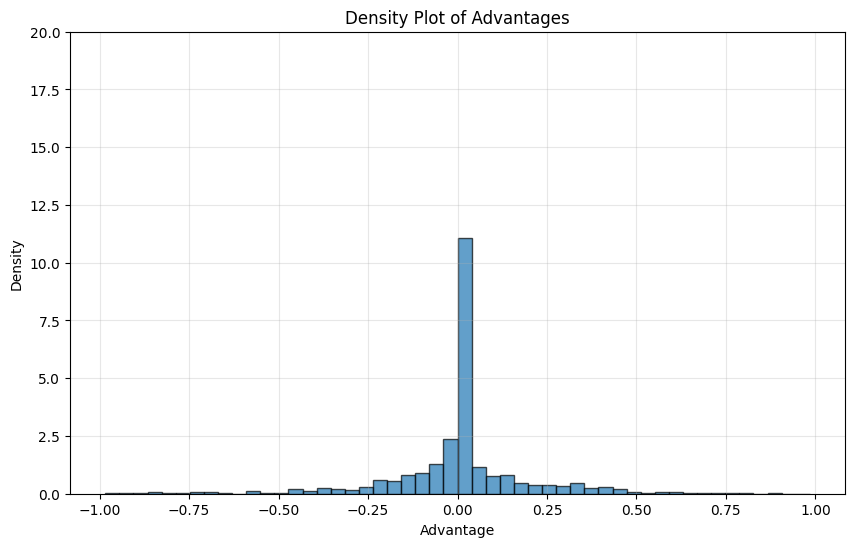

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten all advantages into a single array
all_advantages = []
for x in subset_train_dataset:
    all_advantages.extend(x['advantages'])
all_advantages = np.array(all_advantages)

plt.figure(figsize=(10, 6))
plt.hist(all_advantages, bins=50, density=True, alpha=0.7, edgecolor='black')
plt.xlabel('Advantage')
plt.ylabel('Density')
plt.title('Density Plot of Advantages')
plt.ylim(0, 20)
plt.grid(True, alpha=0.3)
plt.show()